# Config


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

import os
from dotenv import load_dotenv

from entsoe import EntsoePandasClient

load_dotenv()

# ENTSOE Token
entsoe_token = os.getenv("ENTSOE_API_TOKEN")

# ENTSOE Client
entsoe_client = EntsoePandasClient(api_key=entsoe_token)

# Fetch Actual & FCST Load

In [2]:
# Location
country_capital = "Madrid"
country_code = "ES"


# Period
today = pd.Timestamp.now(
    tz=f"Europe/{country_capital}"
).normalize()

yesterday=(pd.Timestamp.now(tz=f"Europe/{country_capital}")
    .normalize()
    - pd.Timedelta(days=1)
)
last_week=(pd.Timestamp.now(tz=f"Europe/{country_capital}")
    .normalize()
    - pd.Timedelta(days=7)
)


start=last_week
end=today

In [3]:
df = entsoe_client.query_load_and_forecast(
    country_code=country_code,
    start=last_week,
    end=today)

df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 672 entries, 2026-08-03 00:00:00+02:00 to 2026-08-09 23:45:00+02:00
Freq: 15min
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Forecasted Load  672 non-null    float64
 1   Actual Load      672 non-null    float64
dtypes: float64(2)
memory usage: 15.8 KB


In [4]:
 df.describe().T

,count,mean,std,min,25%,50%,75%,max
Forecasted Load,672.0,30201.464286,3523.476698,22962.0,27046.5,30786.0,33301.25,35977.0
Actual Load,672.0,30310.130952,3496.554814,23180.0,27149.0,30800.0,33347.00,35768.0


In [5]:
df.head()

,Forecasted Load,Actual Load
2026-08-03 00:00:00+02:00,29203.0,29144.0
2026-08-03 00:15:00+02:00,28704.0,28768.0
2026-08-03 00:30:00+02:00,28209.0,28184.0
2026-08-03 00:45:00+02:00,27727.0,27656.0
2026-08-03 01:00:00+02:00,27207.0,27236.0


In [6]:
df.tail()


,Forecasted Load,Actual Load
2026-08-09 22:45:00+02:00,31417.0,31420.0
2026-08-09 23:00:00+02:00,30880.0,30904.0
2026-08-09 23:15:00+02:00,30315.0,30568.0
2026-08-09 23:30:00+02:00,29775.0,29988.0
2026-08-09 23:45:00+02:00,29259.0,29244.0


In [7]:
# Check that timestamps are unique
assert df.index.is_unique

# Check that timestamps are sorted
assert df.index.is_monotonic_increasing

In [8]:
pivot = pd.pivot_table(
    df,
    values=["Actual Load", "Forecasted Load"],
    index=df.index.date,
    aggfunc="mean"
)

pivot["Delta"] = pivot["Actual Load"] - pivot["Forecasted Load"]

print(pivot.round(2))

            Actual Load  Forecasted Load   Delta
2026-08-03     30934.21         31185.55 -251.34
2026-08-04     30931.54         30981.11  -49.57
2026-08-05     31208.29         31244.61  -36.32
2026-08-06     31583.62         31462.58  121.04
2026-08-07     31354.88         30958.32  396.55
2026-08-08     28915.12         28616.36  298.76
2026-08-09     27243.25         26961.70  281.55


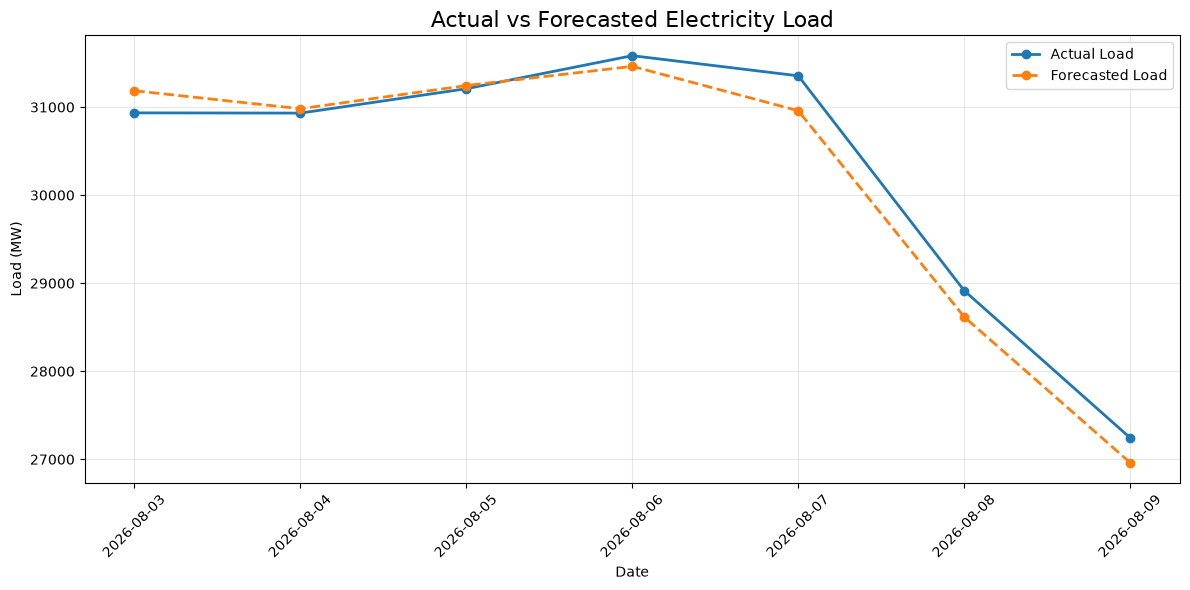

In [9]:
plt.figure(figsize=(12, 6))

plt.plot(
    pivot.index,
    pivot["Actual Load"],
    marker="o",
    linewidth=2,
    label="Actual Load"
)

plt.plot(
    pivot.index,
    pivot["Forecasted Load"],
    marker="o",
    linewidth=2,
    linestyle="--",
    label="Forecasted Load"
)

plt.title("Actual vs Forecasted Electricity Load", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Load (MW)")
plt.legend()
plt.grid(alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

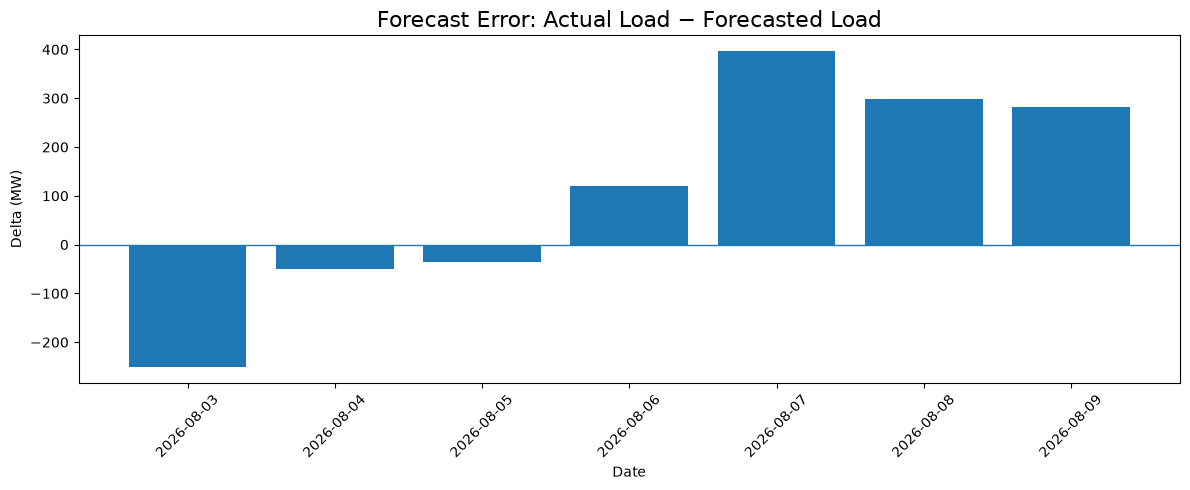

In [10]:
plt.figure(figsize=(12, 5))

plt.bar(
    pivot.index,
    pivot["Delta"]
)

plt.axhline(
    y=0,
    linewidth=1
)

plt.title("Forecast Error: Actual Load − Forecasted Load", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Delta (MW)")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()